In [15]:
import numpy as np
import pandas as pd

import xgboost as xgb

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
path = 'pre_processed.pkl'
df = pd.read_pickle(path)

In [4]:
df.shape

(8465, 16)

In [5]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Day', 'Month', 'Year', 'Weekend_or_Holiday'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8465 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8465 non-null   datetime64[ns]
 1   Rented Bike Count          8465 non-null   int64         
 2   Hour                       8465 non-null   category      
 3   Temperature(°C)            8465 non-null   float64       
 4   Humidity(%)                8465 non-null   int64         
 5   Wind speed (m/s)           8465 non-null   float64       
 6   Visibility (10m)           8465 non-null   int64         
 7   Dew point temperature(°C)  8465 non-null   float64       
 8   Solar Radiation (MJ/m2)    8465 non-null   float64       
 9   Rainfall(mm)               8465 non-null   float64       
 10  Snowfall (cm)              8465 non-null   float64       
 11  Seasons                    8465 non-null   category      
 12  Day        

In [7]:
# For XGBoost, we'll use LabelEncoder for categorical variables
categorical_cols = ['Hour', 'Seasons', 'Day', 'Month', 'Year', 'Weekend_or_Holiday']

# Convert categorical columns to category dtype and get codes
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

In [8]:
# Feature columns (numerical + encoded categorical)
feature_cols = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
                'Visibility (10m)', 'Dew point temperature(°C)',
                'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)'] + categorical_cols

X = df[feature_cols].values
feature_names = feature_cols

In [9]:
y = df['Rented Bike Count'].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6772, 14)
X_test shape: (1693, 14)
y_train shape: (6772,)
y_test shape: (1693,)


In [12]:
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

In [13]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

In [16]:
grid_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [17]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [18]:
best_xgb = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best cross-validation score: 0.9417186776796976


In [19]:
y_pred = best_xgb.predict(X_test)

In [20]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Test set R²: {r2:.6f}")
print(f"Test set MSE: {mse:.6f}")
print(f"Test set RMSE: {rmse:.6f}")

Test set R²: 0.932366
Test set MSE: 26552.228516
Test set RMSE: 162.948546


In [23]:
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importances.head(10))

Top 20 Most Important Features:
                      Feature  Importance
6                Rainfall(mm)    0.282063
8                        Hour    0.184505
9                     Seasons    0.132722
0             Temperature(°C)    0.116486
13         Weekend_or_Holiday    0.101194
5     Solar Radiation (MJ/m2)    0.068248
1                 Humidity(%)    0.042046
11                      Month    0.030841
4   Dew point temperature(°C)    0.016533
10                        Day    0.007988


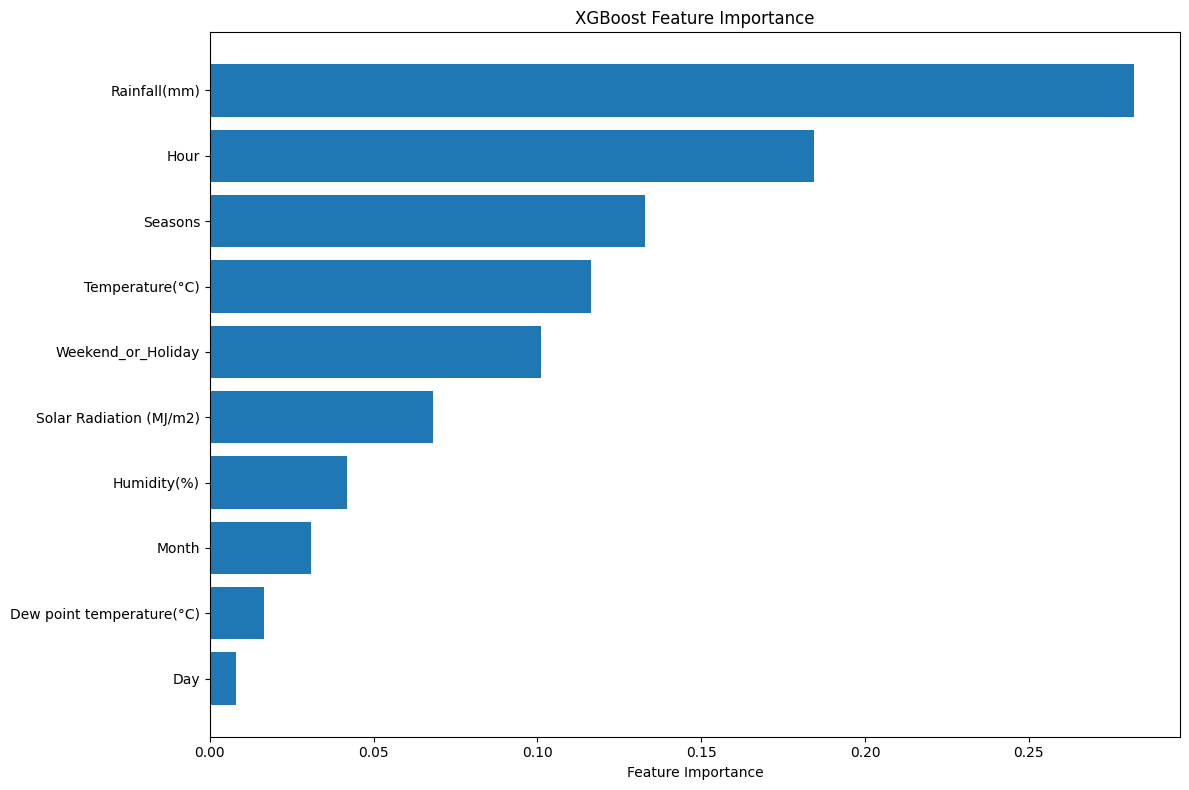

In [24]:
plt.figure(figsize=(12, 8))
top_features = feature_importances.head(10)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()